# ECG Signal Processing

This notebook demonstrates a basic ECG signal-processing pipeline using MIT-BIH Record 100, including preprocessing, R-peak detection, heart-rate estimation, and validation against reference annotations.

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, sosfiltfilt, find_peaks

In [162]:
RECORD_ID = "100"
DURATION_S = 15
DATABASE_FS = 360

LOWCUT_HZ = 0.5
HIGHCUT_HZ = 40.0
FILTER_ORDER = 4

MIN_PEAK_HEIGHT_MV = 0.5
MIN_PEAK_DISTANCE_S = 0.5

MATCH_TOLERANCE_S = 0.1

## 1. Setup and Data

A 15-second segment of MIT-BIH Record 100 is loaded using the WFDB library.

The first ECG channel is used throughout the analysis.

In [163]:
record = wfdb.rdrecord(
    RECORD_ID,
    pn_dir="mitdb",
    sampto=int(DURATION_S * DATABASE_FS)
)

signal = record.p_signal[:, 0]
fs = record.fs
lead_name = record.sig_name[0]

time = np.arange(len(signal)) / fs

print(f"Record: {RECORD_ID}")
print(f"ECG lead: {lead_name}")
print(f"Sampling frequency: {fs} Hz")
print(f"Duration: {len(signal) / fs:.1f} s")

Record: 100
ECG lead: MLII
Sampling frequency: 360 Hz
Duration: 15.0 s


## 2. ECG Preprocessing

A fourth-order Butterworth band-pass filter is applied to reduce baseline drift
and high-frequency noise while preserving the main ECG morphology.

The selected passband is **0.5–40 Hz**.

In [164]:
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    sos = butter(
        order,
        [lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)

In [165]:
filtered_signal = bandpass_filter(
    signal,
    fs,
    LOWCUT_HZ,
    HIGHCUT_HZ,
    FILTER_ORDER
)

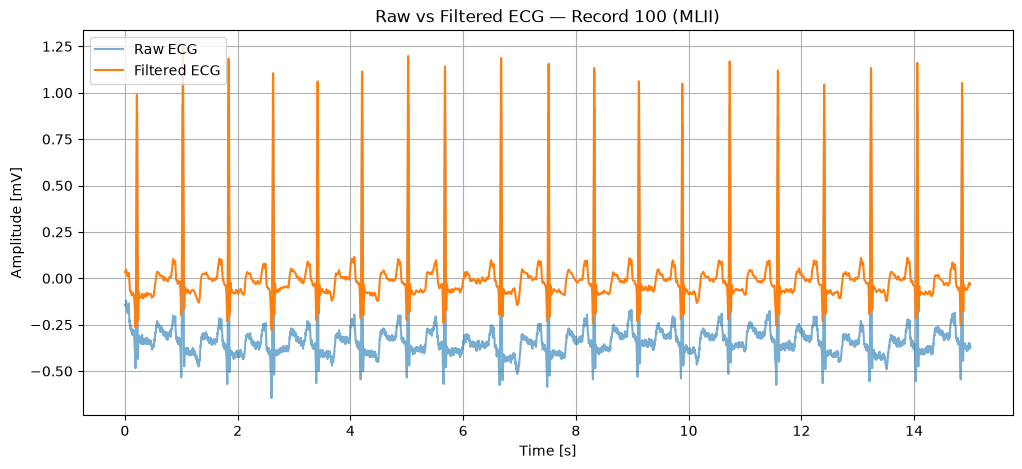

In [166]:
plt.figure(figsize=(12, 5))

plt.plot(time, signal, label="Raw ECG", alpha=0.6)
plt.plot(time, filtered_signal, label="Filtered ECG")

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title(f"Raw vs Filtered ECG — Record {RECORD_ID} ({lead_name})")
plt.legend()
plt.grid()
plt.show()

## 3. R-Peak Detection

R-peaks are detected from the filtered ECG using `scipy.signal.find_peaks`.

Detection parameters:

- minimum peak height: **0.5 mV**
- minimum peak distance: **0.5 s**

The minimum-distance constraint helps prevent multiple detections within the
same cardiac cycle.

In [167]:
filtered_peaks, _ = find_peaks(
    filtered_signal,
    height=MIN_PEAK_HEIGHT_MV,
    distance=int(MIN_PEAK_DISTANCE_S * fs)
)

print(f"Detected R-peaks: {len(filtered_peaks)}")

Detected R-peaks: 19


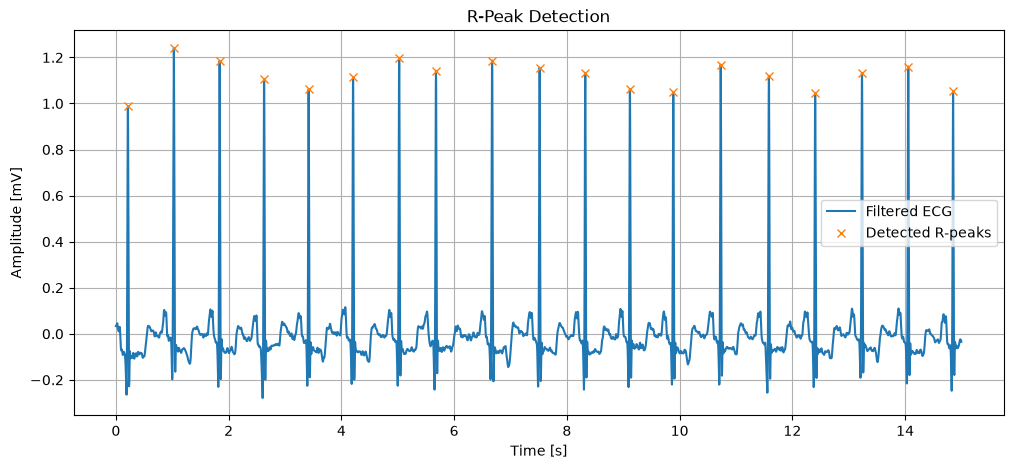

In [168]:
plt.figure(figsize=(12, 5))

plt.plot(time, filtered_signal, label="Filtered ECG")
plt.plot(
    time[filtered_peaks],
    filtered_signal[filtered_peaks],
    "x",
    label="Detected R-peaks"
)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("R-Peak Detection")
plt.legend()
plt.grid()
plt.show()

## 4. Heart-Rate Estimation

RR intervals are calculated from consecutive R-peaks and converted to
beat-to-beat heart rate in beats per minute (BPM).

In [169]:
rr_intervals = np.diff(filtered_peaks) / fs
heart_rate = 60 / rr_intervals

average_hr = np.mean(heart_rate)

print(f"Average heart rate: {average_hr:.1f} BPM")

Average heart rate: 74.2 BPM


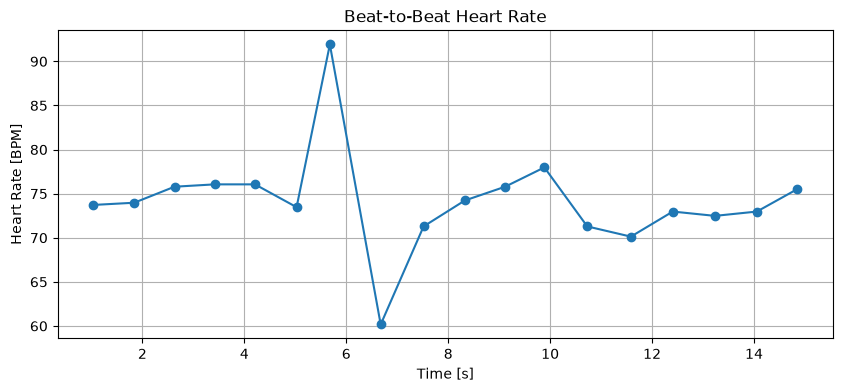

In [170]:
hr_times = time[filtered_peaks[1:]]

plt.figure(figsize=(10, 4))
plt.plot(hr_times, heart_rate, marker="o")

plt.xlabel("Time [s]")
plt.ylabel("Heart Rate [BPM]")
plt.title("Beat-to-Beat Heart Rate")
plt.grid()
plt.show()

## 5. Validation Against Reference Annotations

The detected R-peaks are evaluated against the expert reference annotations
provided with the MIT-BIH Arrhythmia Database.

For this segment:

- `N` — normal beat
- `A` — atrial premature beat

Non-beat annotations such as `+` are excluded from the evaluation.

In [171]:
annotation = wfdb.rdann(
    RECORD_ID,
    "atr",
    pn_dir="mitdb",
    sampto=len(signal)
)

beat_symbols = ["N", "A"]

reference_beats = np.array([
    sample
    for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in beat_symbols
])

print(f"Reference beats: {len(reference_beats)}")

Reference beats: 19


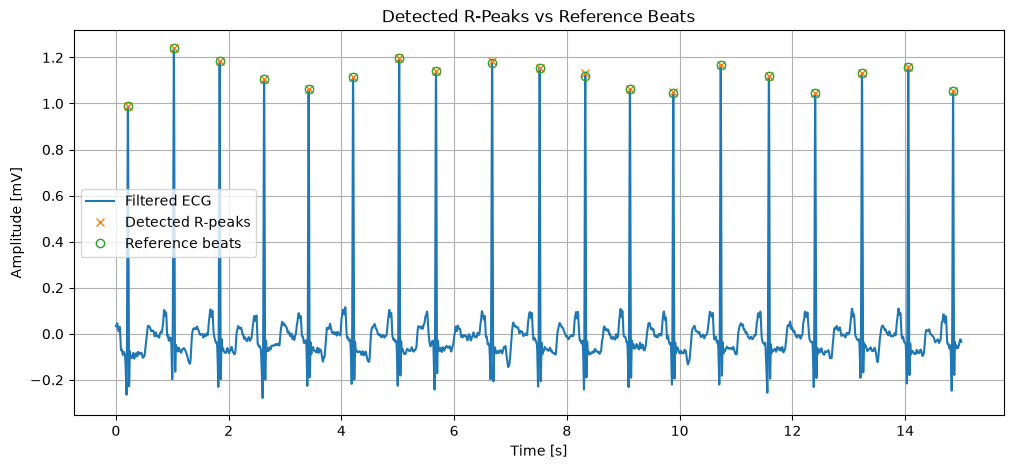

In [172]:
plt.figure(figsize=(12, 5))

plt.plot(time, filtered_signal, label="Filtered ECG")

plt.plot(
    time[filtered_peaks],
    filtered_signal[filtered_peaks],
    "x",
    label="Detected R-peaks"
)

plt.plot(
    time[reference_beats],
    filtered_signal[reference_beats],
    "o",
    fillstyle="none",
    label="Reference beats"
)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("Detected R-Peaks vs Reference Beats")
plt.legend()
plt.grid()
plt.show()

In [173]:
tolerance = int(MATCH_TOLERANCE_S * fs)

matched_reference = set()
true_positives = 0

for detected in filtered_peaks:
    distances = np.abs(reference_beats - detected)

    candidate_indices = np.where(distances <= tolerance)[0]

    unmatched_candidates = [
        idx for idx in candidate_indices
        if idx not in matched_reference
    ]

    if unmatched_candidates:
        nearest_index = min(
            unmatched_candidates,
            key=lambda idx: distances[idx]
        )

        matched_reference.add(nearest_index)
        true_positives += 1

false_positives = len(filtered_peaks) - true_positives
false_negatives = len(reference_beats) - true_positives

sensitivity = true_positives / len(reference_beats)
ppv = true_positives / len(filtered_peaks)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Sensitivity: {sensitivity * 100:.1f}%")
print(f"PPV: {ppv * 100:.1f}%")

True positives: 19
False positives: 0
False negatives: 0
Sensitivity: 100.0%
PPV: 100.0%


## 6. Results

For the analyzed 15-second segment of MIT-BIH Record 100:

| Metric | Result |
| --- | ---: |
| Reference beats | 19 |
| True positives | 19 |
| False positives | 0 |
| False negatives | 0 |
| Sensitivity | 100% |
| Positive Predictive Value (PPV) | 100% |

Detected peaks were matched to reference beats using a tolerance of **100 ms**.

These results are specific to this segment and do not represent detector
performance across the complete MIT-BIH database.

## 7. Limitations and Next Steps

This analysis is a proof of concept based on a single 15-second segment from
MIT-BIH Record 100.

The R-peak detection parameters used here have not yet been validated across
different patients, rhythms, ECG morphologies, or noise conditions.

Future work will include:

- evaluation across additional MIT-BIH records
- analysis of longer ECG recordings
- parameter robustness testing
- heart-rate variability analysis
- ECG feature extraction
- arrhythmia classification

The current implementation is intended for biomedical signal-processing
experimentation and is not a clinically validated detection system.